In [1]:
import sys
sys.path.append('../')
import numpy as np
import qutip as qt
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

from multiprocessing import Pool

import utils_2Q_gate_zp as ut
from X_gate_fidelity_optimize import get_propagator, get_fidelity_super_operator, drive_gauss_A, drive_gauss_B, xgate_fidelity_log, xgate_fidelity_log_noise, print_soln, xgate_fidelity_parallel, truncate_2
from truncation_estimate import make_leakage_df, trunc_by_graph_estimate, make_rate_graph, shortest_path_to_core, trunc_by_thresh

In [2]:
drive_phi, drive_theta, truc = False, True, 100
# drive_phi, drive_theta, truc = True, False, 30
parallel = False
folder = 'data/data_xgate_theta_3ncut.txt' if drive_theta else 'data/data_xgate_phi.txt'
f_xgate = pd.read_csv(folder)
params = f_xgate[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']].to_numpy()
n_cpu, n_job = 4, len(params)
logi_state = [0, 2]
# [H0, drive_term, w_trans_1, w_trans_2, _] = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc)
folder = f'data/data_one_zeropi_truncation=1000/'
evals = 2*np.pi* pd.read_csv(folder+ 'evals.txt').to_numpy().flatten()
n_theta = 2*np.pi* pd.read_csv(folder+ 'n_theta.txt').to_numpy()
n_phi = 2*np.pi* pd.read_csv(folder+ 'n_phi.txt').map(complex).to_numpy()
gate_target = qt.sigmax()
gamma2 =  1 / 1600e3
# gammas =  1 / 2e3
gammas = 1 / 5e3
gamma2_p = 0 / 100e3
# ratio = 10
# gammas =  gamma_2 * ratio
# gammas_p = 1 / 9000
gammas_p = 1 / 5e3

jump_t1   = []
jump_tphi = []
gamma_t1   = [0, gammas,  gamma2]  + [gammas]  * (truc-3)
gamma_tphi = [0, gammas_p, gamma2_p] + [gammas_p] * (truc-3)
for i in range(1,truc):
    jump_t1.append( np.sqrt(gamma_t1[i]) * qt.basis(truc,0) * qt.basis(truc,i).dag() )
    jump_tphi.append( np.sqrt(2*gamma_tphi[i]) * qt.basis(truc,i).proj() )

H0 = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_theta
hilbert_space = np.arange(truc).tolist()
H0_truc = truncate_2(H0, hilbert_space)
drive_truc = truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, drive_gauss_A],
                        [drive_truc, drive_gauss_B],]
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta, '; truc = ', truc)
print('parallel = ', parallel)
print('params =')
for para in params:
    print(para.tolist(), ',')
print("n_cpu = ", n_cpu, ";   n_job = ", n_job)
print("gamma_2 = ", gamma2, "gamma_p2 = ", gamma2_p)
print("gammas = ", gammas, "gammas_p = ", gammas_p)
print(f"T1_2 = {1/gamma2} ns") if gamma2 != 0 else None
print(f"T1_other = {1/gammas} ns") if gammas != 0 else None
print(f"Tphi_2 = {1/gamma2_p} ns") if gamma2_p != 0 else None
print(f"Tphi_other = {1/gammas_p} ns") if gammas_p != 0 else None

drive_phi= False ; drive_theta =  True ; truc =  100
parallel =  False
params =
[10.108462, 0.41212, 0.073451, -0.084451, -0.044706] ,
[15.074864, 0.303821, 0.065666, -0.036206, -0.016563] ,
[20.041257, 0.241329, 0.059044, -0.019402, -0.009802] ,
[25.020473, 0.180208, 0.046132, -0.003789, 0.001544] ,
[30.008342, 0.14538, 0.037985, 0.000555, 0.004004] ,
[34.999249, 0.121737, 0.032287, 0.001883, 0.004348] ,
[39.991616, 0.105045, 0.028058, 0.002171, 0.003988] ,
[45.572873, 0.091013, 0.02446, 0.002106, 0.003479] ,
[50.273181, 0.081831, 0.022089, 0.001944, 0.003051] ,
[55.267933, 0.073988, 0.020007, 0.001756, 0.002668] ,
[59.087483, 0.068953, 0.018674, 0.001617, 0.002406] ,
[64.670376, 0.062708, 0.017016, 0.001421, 0.002077] ,
[69.959457, 0.05777, 0.0157, 0.001257, 0.001811] ,
[79.950621, 0.050323, 0.013699, 0.001008, 0.001432] ,
[89.941952, 0.044576, 0.012149, 0.000826, 0.001154] ,
[99.933664, 0.040022, 0.010918, 0.000683, 0.000949] ,
[109.925465, 0.036325, 0.009915, 0.000575, 0.000792] ,


# Test the convergence of the 30 second pulse

In [3]:
p = params[4]
p

array([3.0008342e+01, 1.4538000e-01, 3.7985000e-02, 5.5500000e-04,
       4.0040000e-03])

In [4]:
args = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu]
xgate_fidelity_parallel(p, *args)

-3.433376752086613

In [ ]:
# c_op_list = jump_t1 + jump_tphi
# args_noise = [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]
# xgate_fidelity_log_noise(p, *args_noise)

In [6]:
wd1 = w_trans_1+2*np.pi*p[3]
A1 = p[1]
G = make_rate_graph(drive_term, evals, wd1, A1)

In [7]:
df1 = make_leakage_df([0, 2, 7], drive_term, evals, w_trans_1+2*np.pi*p[3], p[1], G=G)

100%|██████████| 1000/1000 [03:01<00:00,  5.52it/s]


In [8]:
df2 = make_leakage_df([0, 2, 7], drive_term, evals, w_trans_2+2*np.pi*p[4], p[2])

100%|██████████| 1000/1000 [03:00<00:00,  5.55it/s]


In [14]:
df = pd.concat([df1, df2]).sort_values("path_len", ascending=False).drop_duplicates("i", keep="first")
df.iloc[:30]

,i,path,path_len
0,0,0,1.000000e+00
2,2,2,1.000000e+00
7,7,"0,7",2.084306e-03
1,1,"0,1",1.471373e-05
5,5,"2,5",1.058616e-05
11,11,"0,7,11",4.633022e-08
8,8,"0,7,8",3.787448e-08
12,12,"2,12",2.164080e-08
25,25,"0,7,25",1.431220e-08
18,18,"0,7,18",6.112028e-09


In [10]:
def test_pulse(hilbert_space):
    args = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu]
    return xgate_fidelity_parallel(p, *args)

In [ ]:
vals = []
for i in tqdm(range(500)):
    vals.append(trunc_by_thresh([0, 2, 7], drive_term, total_trunc=i))
how_many = [len(v) for v in vals]
how_many.index(13)

100%|██████████| 500/500 [00:22<00:00, 21.77it/s] 


[[0, 2, 7],
 [0, 2, 7],
 [0, 1, 2, 7],
 [0, 1, 2, 7],
 [0, 1, 2, 7],
 [0, 1, 2, 4, 7],
 [0, 1, 2, 4, 5, 7],
 [0, 1, 2, 4, 5, 7],
 [0, 1, 2, 4, 5, 7],
 [0, 1, 2, 4, 5, 7, 8],
 [0, 1, 2, 4, 5, 7, 8],
 [0, 1, 2, 4, 5, 7, 8],
 [0, 1, 2, 4, 5, 7, 8, 11],
 [0, 1, 2, 4, 5, 7, 8, 11, 12],
 [0, 1, 2, 4, 5, 7, 8, 11, 12],
 [0, 1, 2, 4, 5, 7, 8, 11, 12],
 [0, 1, 2, 4, 5, 7, 8, 11, 12],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21, 23],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21, 23],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21, 23, 25],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21, 23, 25],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18, 21, 23, 25, 27],
 [0, 1, 2, 4, 5, 7, 8, 11, 12, 16, 17, 18,

In [22]:
test_truncs = np.linspace(10, 250, 15)
fids_g = np.zeros_like(test_truncs)
fids_n = np.zeros_like(test_truncs)
fids_t = np.zeros_like(test_truncs)
for i,t in enumerate(tqdm(test_truncs)):
    t = int(t)
    by_graph = sorted(df.i.values[:t])
    by_n = list(np.arange(t))
    by_thresh = trunc_by_thresh([0, 2, 7], drive_term, total_trunc=how_many.index(t))
    fids_g[i] = test_pulse(by_graph)
    fids_n[i] = test_pulse(by_n)
    fids_t[i] = test_pulse(by_thresh)

100%|██████████| 15/15 [03:19<00:00, 13.33s/it]


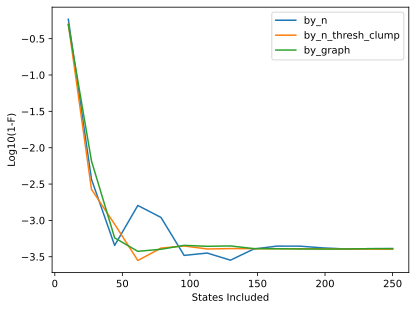

In [23]:
plt.plot(test_truncs, fids_n, label="by_n");
plt.plot(test_truncs, fids_t, label="by_n_thresh_clump");
plt.plot(test_truncs, fids_g, label="by_graph");
plt.ylabel("Log10(1-F)")
plt.xlabel("States Included")
plt.legend();

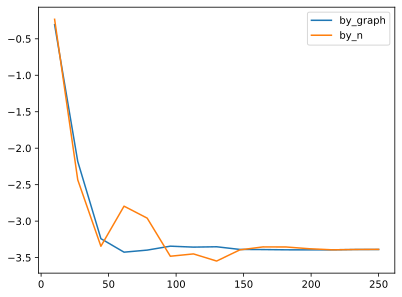

In [13]:
plt.plot(test_truncs, fids_g, label="by_graph");
plt.plot(test_truncs, fids_n, label="by_n");
plt.legend();